Домашняя работа 2

problem 1

График для x = -3


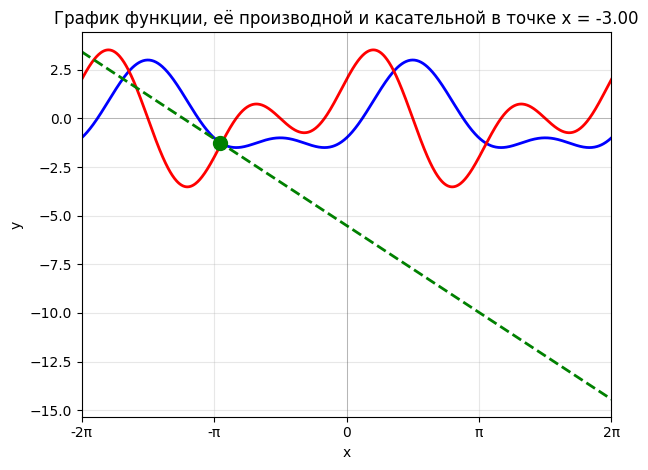

График для x = -2


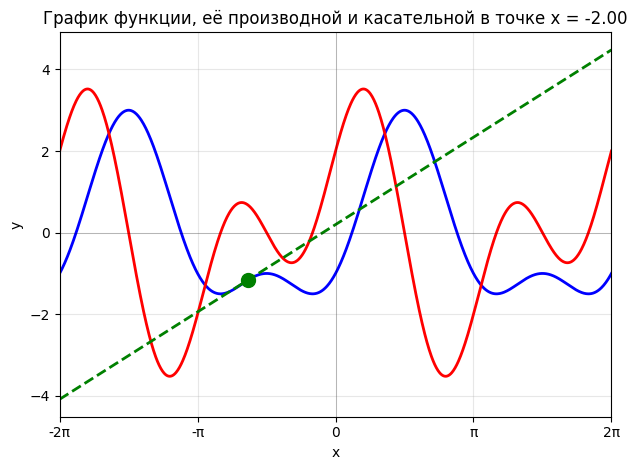

График для x = 1.7


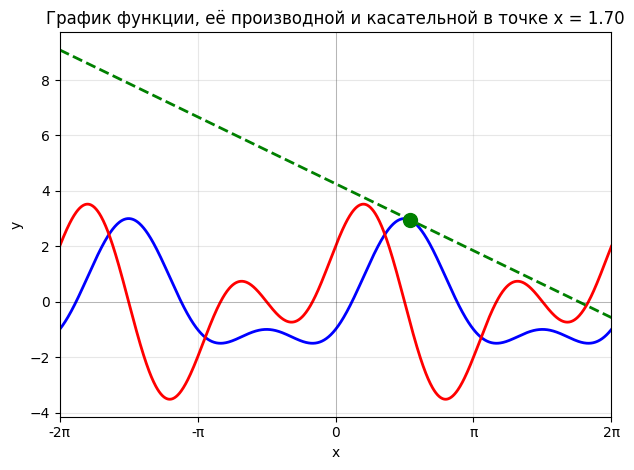

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def beauty_derivative_plot(x0):
    x = np.linspace(-2*np.pi, 2*np.pi, 1000)
    f = 2*np.sin(x) - np.cos(2*x)
    f_derivative = 2*np.cos(x) + 2*np.sin(2*x)
    f_x0 = 2*np.sin(x0) - np.cos(2*x0)
    f_derivative_x0 = 2*np.cos(x0) + 2*np.sin(2*x0)
    tangent_line = f_x0 + f_derivative_x0 * (x - x0)
    plt.plot(x, f, 'b-', linewidth=2)
    plt.plot(x, f_derivative, 'r-', linewidth=2)
    plt.plot(x, tangent_line, 'g--', linewidth=2)
    plt.plot(x0, f_x0, 'go', markersize=10)
    plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'График функции, её производной и касательной в точке x = {x0:.2f}')
    plt.xlim(-2*np.pi, 2*np.pi)
    plt.xticks([-2*np.pi, -np.pi, 0, np.pi, 2*np.pi],['-2π', '-π', '0', 'π', '2π'])
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("График для x = -3")
    beauty_derivative_plot(-3)

    print("График для x = -2")
    beauty_derivative_plot(-2)

    print("График для x = 1.7")
    beauty_derivative_plot(1.7)

problem 2

Data loaded successfully

TASK 1


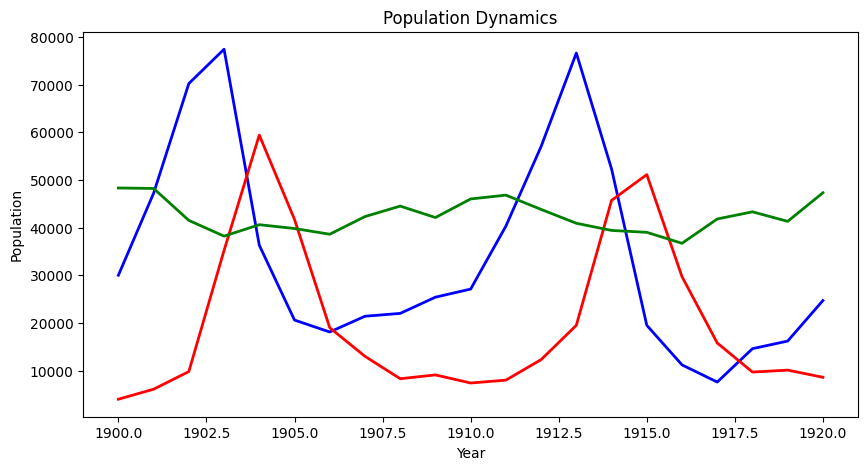


TASK 2
Maximum hares: Year 1903, Value 77400.0
Maximum lynxes: Year 1904, Value 59400.0
Maximum carrots: Year 1900, Value 48300.0

TASK 3


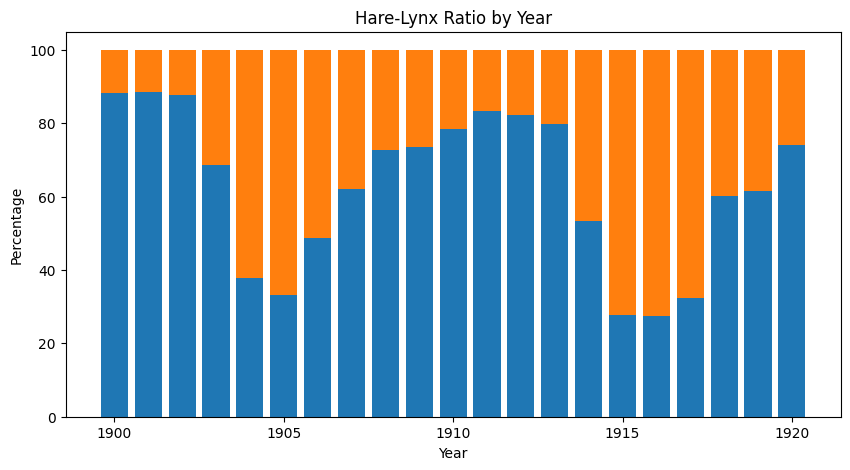


TASK 4
Mean hares: 34081.0
Mean lynxes: 20166.7
Mean carrots: 42400.0


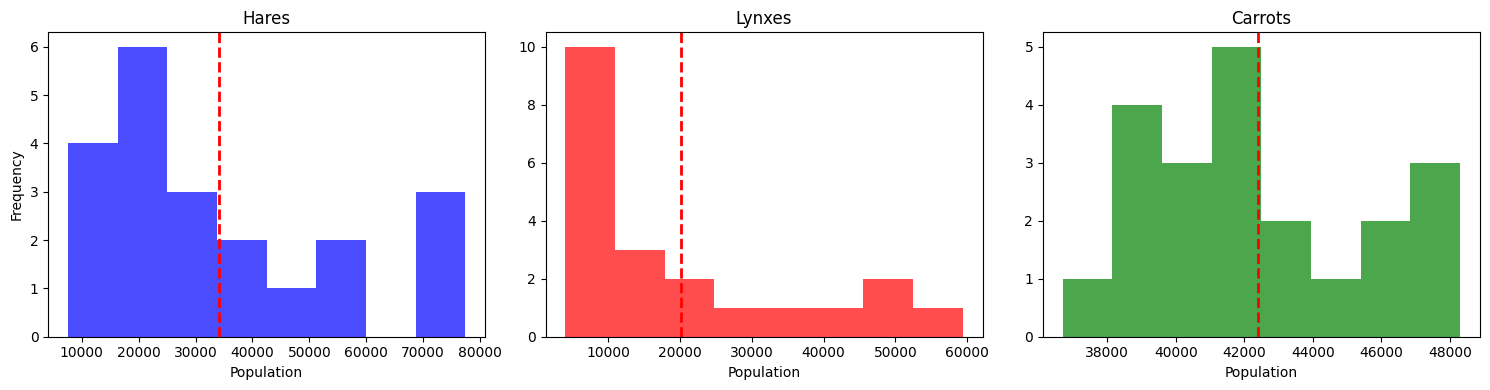


TASK 5
Year-by-year comparison:
Year  Hares  Lynxes  Dominant
1900   30000    4000      H
1901   47200    6100      H
1902   70200    9800      H
1903   77400   35200      H
1904   36300   59400      L
1905   20600   41700      L
1906   18100   19000      L
1907   21400   13000      H
1908   22000    8300      H
1909   25400    9100      H
1910   27100    7400      H
1911   40300    8000      H
1912   57000   12300      H
1913   76600   19500      H
1914   52300   45700      H
1915   19500   51100      L
1916   11200   29700      L
1917    7600   15800      L
1918   14600    9700      H
1919   16200   10100      H
1920   24700    8600      H

Hares dominant in 15 years
Lynxes dominant in 6 years


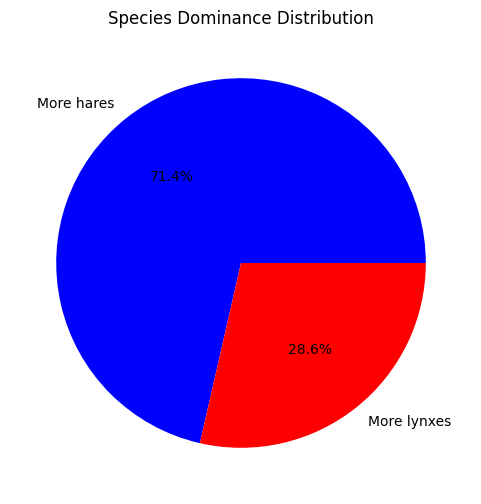


TASK 6


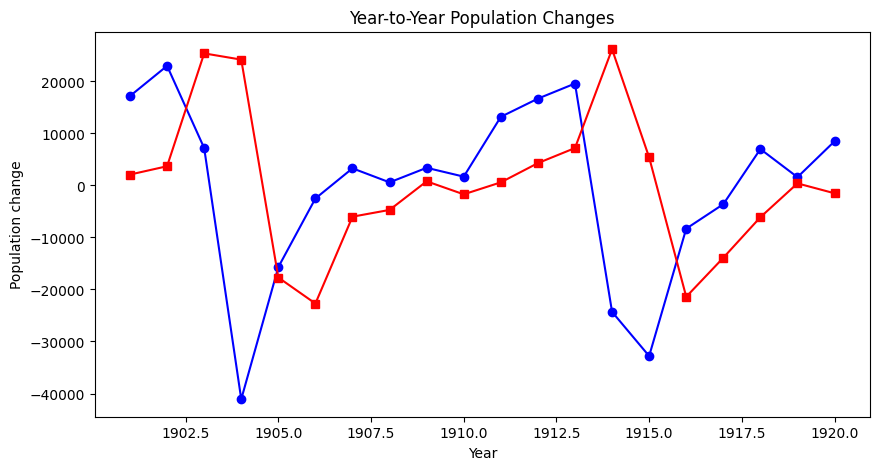


TASK 7


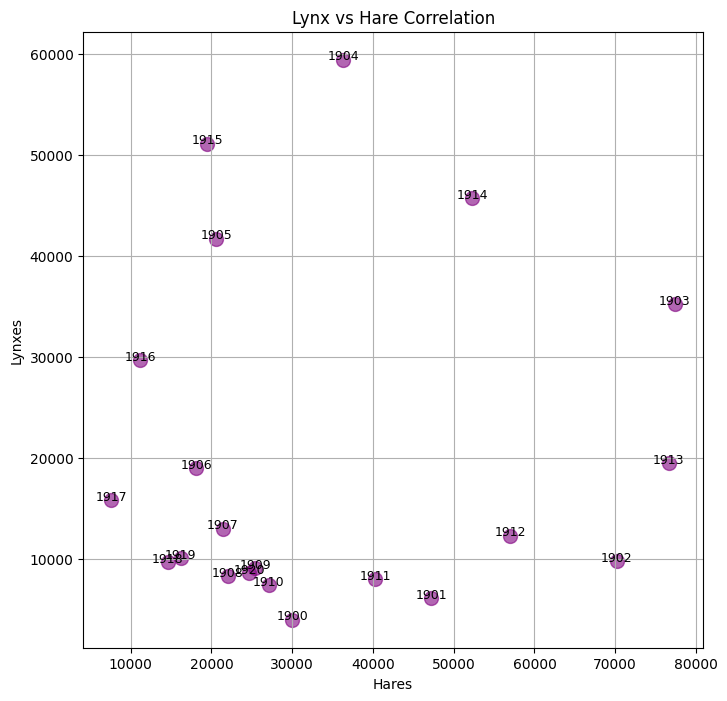


TASK 8
Actual value in 1920: 24700.0
Using data from years: [np.float64(1900.0), np.float64(1901.0), np.float64(1902.0), np.float64(1903.0), np.float64(1904.0), np.float64(1905.0), np.float64(1906.0), np.float64(1907.0), np.float64(1908.0), np.float64(1909.0), np.float64(1910.0), np.float64(1911.0), np.float64(1912.0), np.float64(1913.0), np.float64(1914.0), np.float64(1915.0), np.float64(1916.0), np.float64(1917.0), np.float64(1918.0), np.float64(1919.0)]
Estimate (mean of previous years): 34550.0
Error: 9850.0


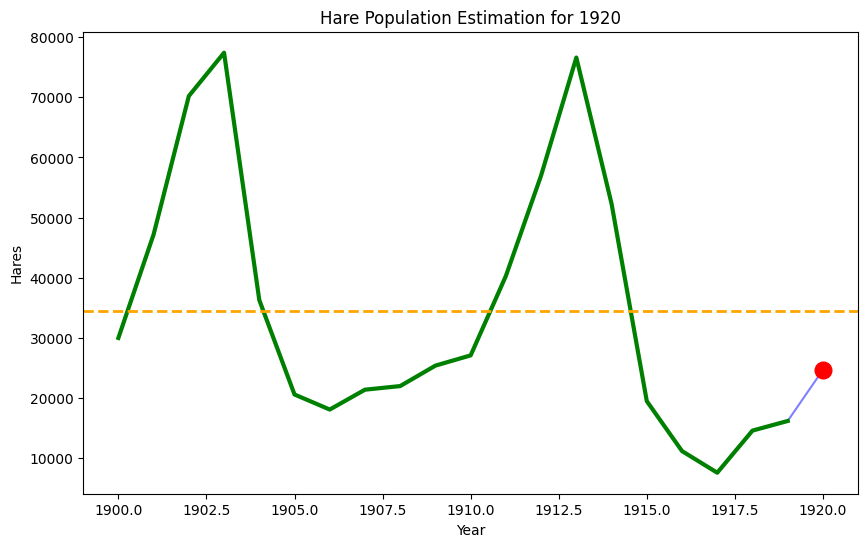

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import StringIO

def load_population_data():
    file_id = '15WG5kwiq72NdaFpTlmWv0BTpM3ywwJGD'
    download_url = f'https://drive.google.com/uc?export=download&id={file_id}'

    try:
        response = requests.get(download_url)
        response.raise_for_status()
        data_str = response.text
        data = np.loadtxt(StringIO(data_str))
        print("Data loaded successfully")

    except Exception as e:
        print("Download failed, using local data")
        data = np.loadtxt(StringIO(data_str))

    return data

data = load_population_data()
years = data[:, 0]
hares = data[:, 1]
lynxes = data[:, 2]
carrots = data[:, 3]


print("\nTASK 1")

plt.figure(figsize=(10, 5))
plt.plot(years, hares, 'b-', label='Hares', linewidth=2)
plt.plot(years, lynxes, 'r-', label='Lynxes', linewidth=2)
plt.plot(years, carrots, 'g-', label='Carrots', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Population Dynamics')
plt.show()


print("\nTASK 2")

max_hare_idx = 0
max_hare_val = hares[0]
for i in range(len(hares)):
    if hares[i] > max_hare_val:
        max_hare_val = hares[i]
        max_hare_idx = i

max_lynx_idx = 0
max_lynx_val = lynxes[0]
for i in range(len(lynxes)):
    if lynxes[i] > max_lynx_val:
        max_lynx_val = lynxes[i]
        max_lynx_idx = i

max_carrot_idx = 0
max_carrot_val = carrots[0]
for i in range(len(carrots)):
    if carrots[i] > max_carrot_val:
        max_carrot_val = carrots[i]
        max_carrot_idx = i

print(f"Maximum hares: Year {years[max_hare_idx]:.0f}, Value {max_hare_val}")
print(f"Maximum lynxes: Year {years[max_lynx_idx]:.0f}, Value {max_lynx_val}")
print(f"Maximum carrots: Year {years[max_carrot_idx]:.0f}, Value {max_carrot_val}")

print("\nTASK 3")

plt.figure(figsize=(10, 5))
hare_pct = []
lynx_pct = []

for i in range(len(hares)):
    total = hares[i] + lynxes[i]
    if total > 0:
        hare_pct.append(hares[i] / total * 100)
        lynx_pct.append(lynxes[i] / total * 100)
    else:
        hare_pct.append(50)
        lynx_pct.append(50)

p1 = plt.bar(years, hare_pct, label='Hares %')
p2 = plt.bar(years, lynx_pct, bottom=hare_pct, label='Lynxes %')

plt.xlabel('Year')
plt.ylabel('Percentage')
plt.title('Hare-Lynx Ratio by Year')
plt.show()

print("\nTASK 4")

sum_hares = 0
for x in hares:
    sum_hares += x
mean_hares = sum_hares / len(hares)

sum_lynxes = 0
for x in lynxes:
    sum_lynxes += x
mean_lynxes = sum_lynxes / len(lynxes)

sum_carrots = 0
for x in carrots:
    sum_carrots += x
mean_carrots = sum_carrots / len(carrots)

print(f"Mean hares: {mean_hares:.1f}")
print(f"Mean lynxes: {mean_lynxes:.1f}")
print(f"Mean carrots: {mean_carrots:.1f}")

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(hares, bins=8, color='blue', alpha=0.7)
plt.axvline(mean_hares, color='red', linestyle='--', linewidth=2)
plt.title('Hares')
plt.xlabel('Population')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(lynxes, bins=8, color='red', alpha=0.7)
plt.axvline(mean_lynxes, color='red', linestyle='--', linewidth=2)
plt.title('Lynxes')
plt.xlabel('Population')

plt.subplot(1, 3, 3)
plt.hist(carrots, bins=8, color='green', alpha=0.7)
plt.axvline(mean_carrots, color='red', linestyle='--', linewidth=2)
plt.title('Carrots')
plt.xlabel('Population')

plt.tight_layout()
plt.show()

print("\nTASK 5")

h_count = 0
l_count = 0
comparison = []

for i in range(len(hares)):
    if hares[i] > lynxes[i]:
        comparison.append('H')
        h_count += 1
    else:
        comparison.append('L')
        l_count += 1

print("Year-by-year comparison:")
print("Year  Hares  Lynxes  Dominant")
for i in range(len(years)):
    print(f"{int(years[i]):4d}  {hares[i]:6.0f}  {lynxes[i]:6.0f}      {comparison[i]}")

print(f"\nHares dominant in {h_count} years")
print(f"Lynxes dominant in {l_count} years")

plt.figure(figsize=(6, 6))
plt.pie([h_count, l_count], labels=['More hares', 'More lynxes'],
        autopct='%1.1f%%', colors=['blue', 'red'])
plt.title('Species Dominance Distribution')
plt.show()

print("\nTASK 6")

hare_change = []
lynx_change = []
change_years = []

for i in range(1, len(hares)):
    hare_change.append(hares[i] - hares[i-1])
    lynx_change.append(lynxes[i] - lynxes[i-1])
    change_years.append(years[i])

plt.figure(figsize=(10, 5))
plt.plot(change_years, hare_change, 'b-o', label='Hare change')
plt.plot(change_years, lynx_change, 'r-s', label='Lynx change')
plt.xlabel('Year')
plt.ylabel('Population change')
plt.title('Year-to-Year Population Changes')
plt.show()

print("\nTASK 7")

plt.figure(figsize=(8, 8))
plt.scatter(hares, lynxes, s=100, alpha=0.6, color='purple')
plt.xlabel('Hares')
plt.ylabel('Lynxes')
plt.title('Lynx vs Hare Correlation')

for i in range(len(years)):
    plt.annotate(str(int(years[i])), (hares[i], lynxes[i]),
                 fontsize=9, ha='center')

plt.grid(True)
plt.show()

print("\nTASK 8")

idx_1920 = -1
for i in range(len(years)):
    if years[i] == 1920:
        idx_1920 = i
        break

if idx_1920 >= 0:
    true_val = hares[idx_1920]
    print(f"Actual value in 1920: {true_val}")

    prev_hares = []
    prev_years = []
    for i in range(idx_1920):
        prev_hares.append(hares[i])
        prev_years.append(years[i])

    print(f"Using data from years: {prev_years}")

    sum_prev = 0
    for x in prev_hares:
        sum_prev += x
    mean_prev = sum_prev / len(prev_hares)

    print(f"Estimate (mean of previous years): {mean_prev:.1f}")
    print(f"Error: {abs(true_val - mean_prev):.1f}")

    plt.figure(figsize=(10, 6))

    plt.plot(years, hares, 'b-', label='All data', alpha=0.5)
    plt.plot(prev_years, prev_hares, 'g-', linewidth=3, label='Pre-1920 data')
    plt.plot(1920, true_val, 'ro', markersize=12, label='Actual value')
    plt.axhline(y=mean_prev, color='orange', linestyle='--',
                linewidth=2, label='Estimate (mean)')

    plt.xlabel('Year')
    plt.ylabel('Hares')
    plt.title('Hare Population Estimation for 1920')
    plt.show()

else:
    print("Year 1920 not found in dataset!")